In [19]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [20]:
fruit = pd.read_csv("cleaned_produce.csv")
df = fruit.pivot_table(index="date", columns="productname", values="averageretail")
print(df["Strawberries"])
chosen_fruit = df["Carrots"]

date
1999-10-24    2.696667
1999-10-31    2.696667
1999-11-07    3.303333
1999-11-14    3.473333
1999-11-21    3.473333
                ...   
2019-04-21    2.820000
2019-04-28    2.710000
2019-05-05    2.483333
2019-05-12    2.600000
2019-05-19    2.253333
Name: Strawberries, Length: 1019, dtype: float64


In [21]:
df.index = pd.to_datetime(df.index)
df.index.month

Index([10, 10, 11, 11, 11, 11, 12, 12, 12, 12,
       ...
        3,  3,  3,  4,  4,  4,  4,  5,  5,  5],
      dtype='int32', name='date', length=1019)

In [22]:
def detrending(fruit_series):
    # generate dataframe
    new_df = pd.DataFrame()
    new_df["fruit"] = fruit_series
    new_df.index = pd.to_datetime(new_df.index)   # conver the index to datetime for convenience
    new_df = new_df.sort_index()

    # estimate trend using centered moving average (2x12)
    new_df["trend_estimate"] = new_df["fruit"].rolling(12).mean().rolling(2).mean().shift(-6)

    # detrend and get seasonality
    new_df["detrended"] = new_df["fruit"] - new_df["trend_estimate"]
    seasonality = new_df.groupby(new_df.index.month)["detrended"].mean()
    adjusted = seasonality - seasonality.mean()
    new_df["seasonal_estimate"] = new_df.index.month.map(adjusted)

    # get residuals
    new_df["residuals"] = new_df["fruit"] - new_df["trend_estimate"]

    return new_df


In [23]:
ddf = detrending(chosen_fruit)
ddf

,fruit,trend_estimate,detrended,seasonal_estimate,residuals
date,,,,,
1999-10-24,0.690000,NaN,NaN,0.005127,NaN
1999-10-31,0.573333,NaN,NaN,0.005127,NaN
1999-11-07,0.576667,NaN,NaN,0.002391,NaN
1999-11-14,0.553333,NaN,NaN,0.002391,NaN
1999-11-21,0.606667,NaN,NaN,0.002391,NaN
...,...,...,...,...,...
2019-04-21,1.033333,NaN,NaN,-0.001255,NaN
2019-04-28,1.033333,NaN,NaN,-0.001255,NaN
2019-05-05,1.066667,NaN,NaN,0.004721,NaN


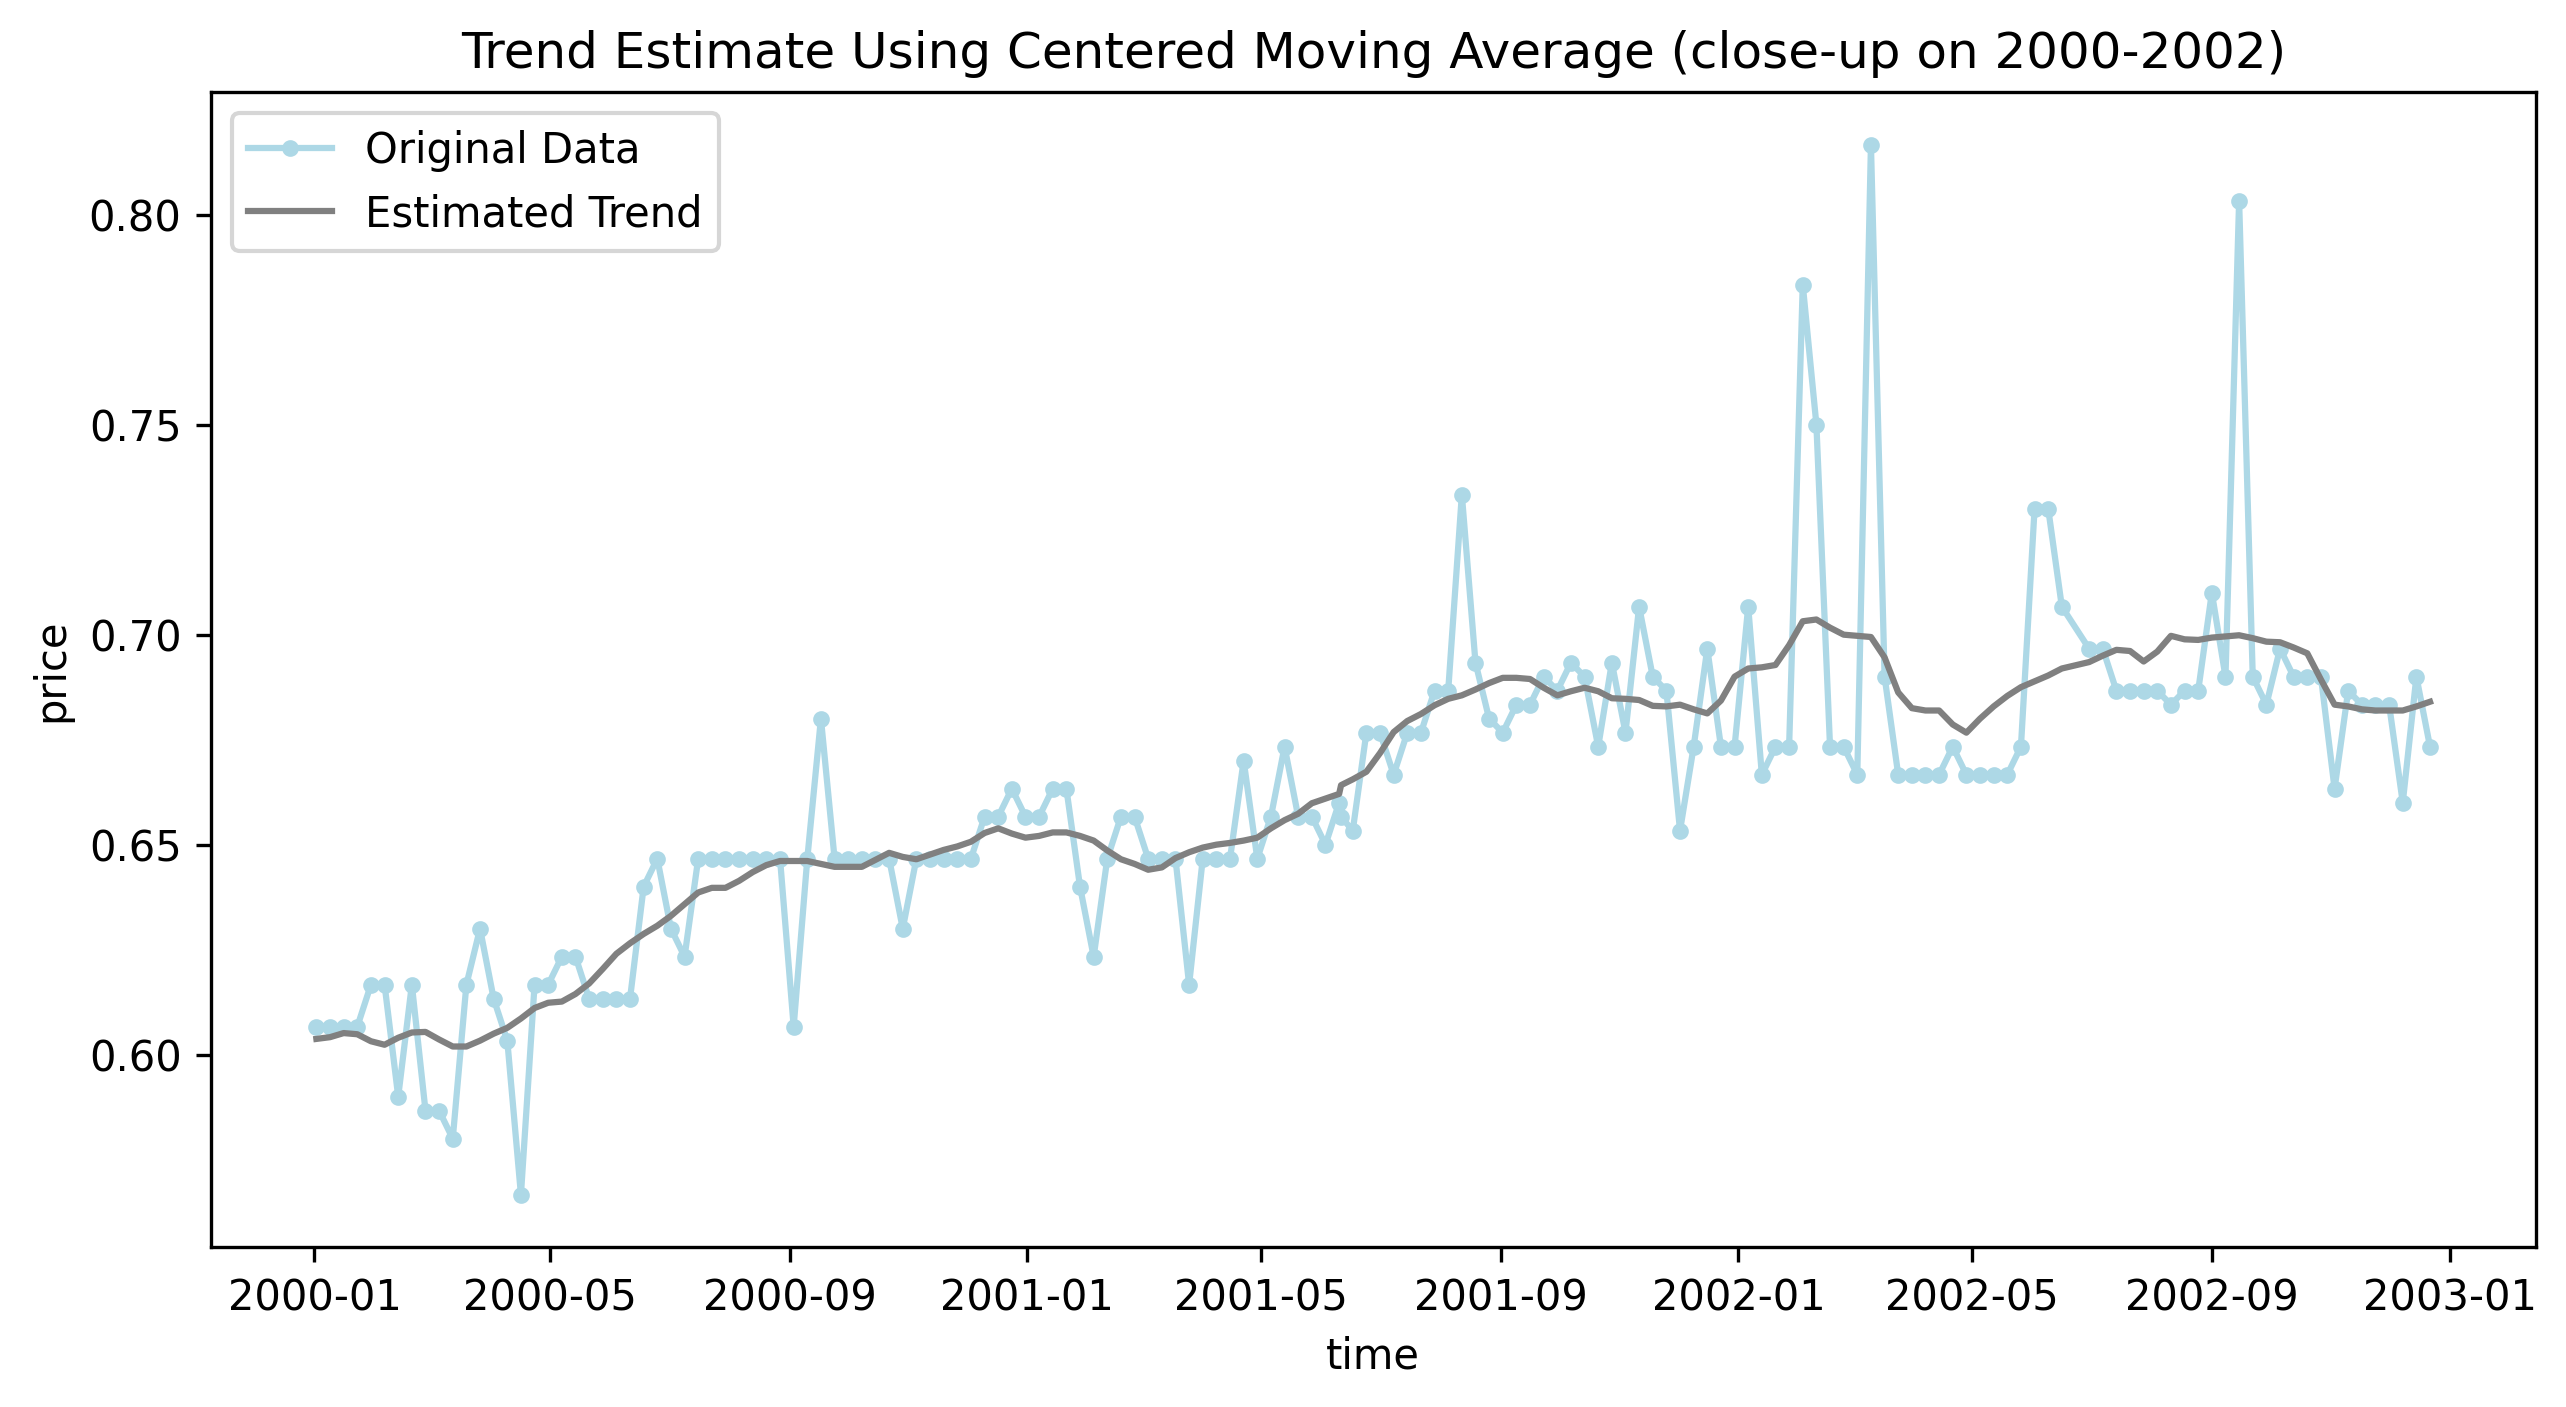

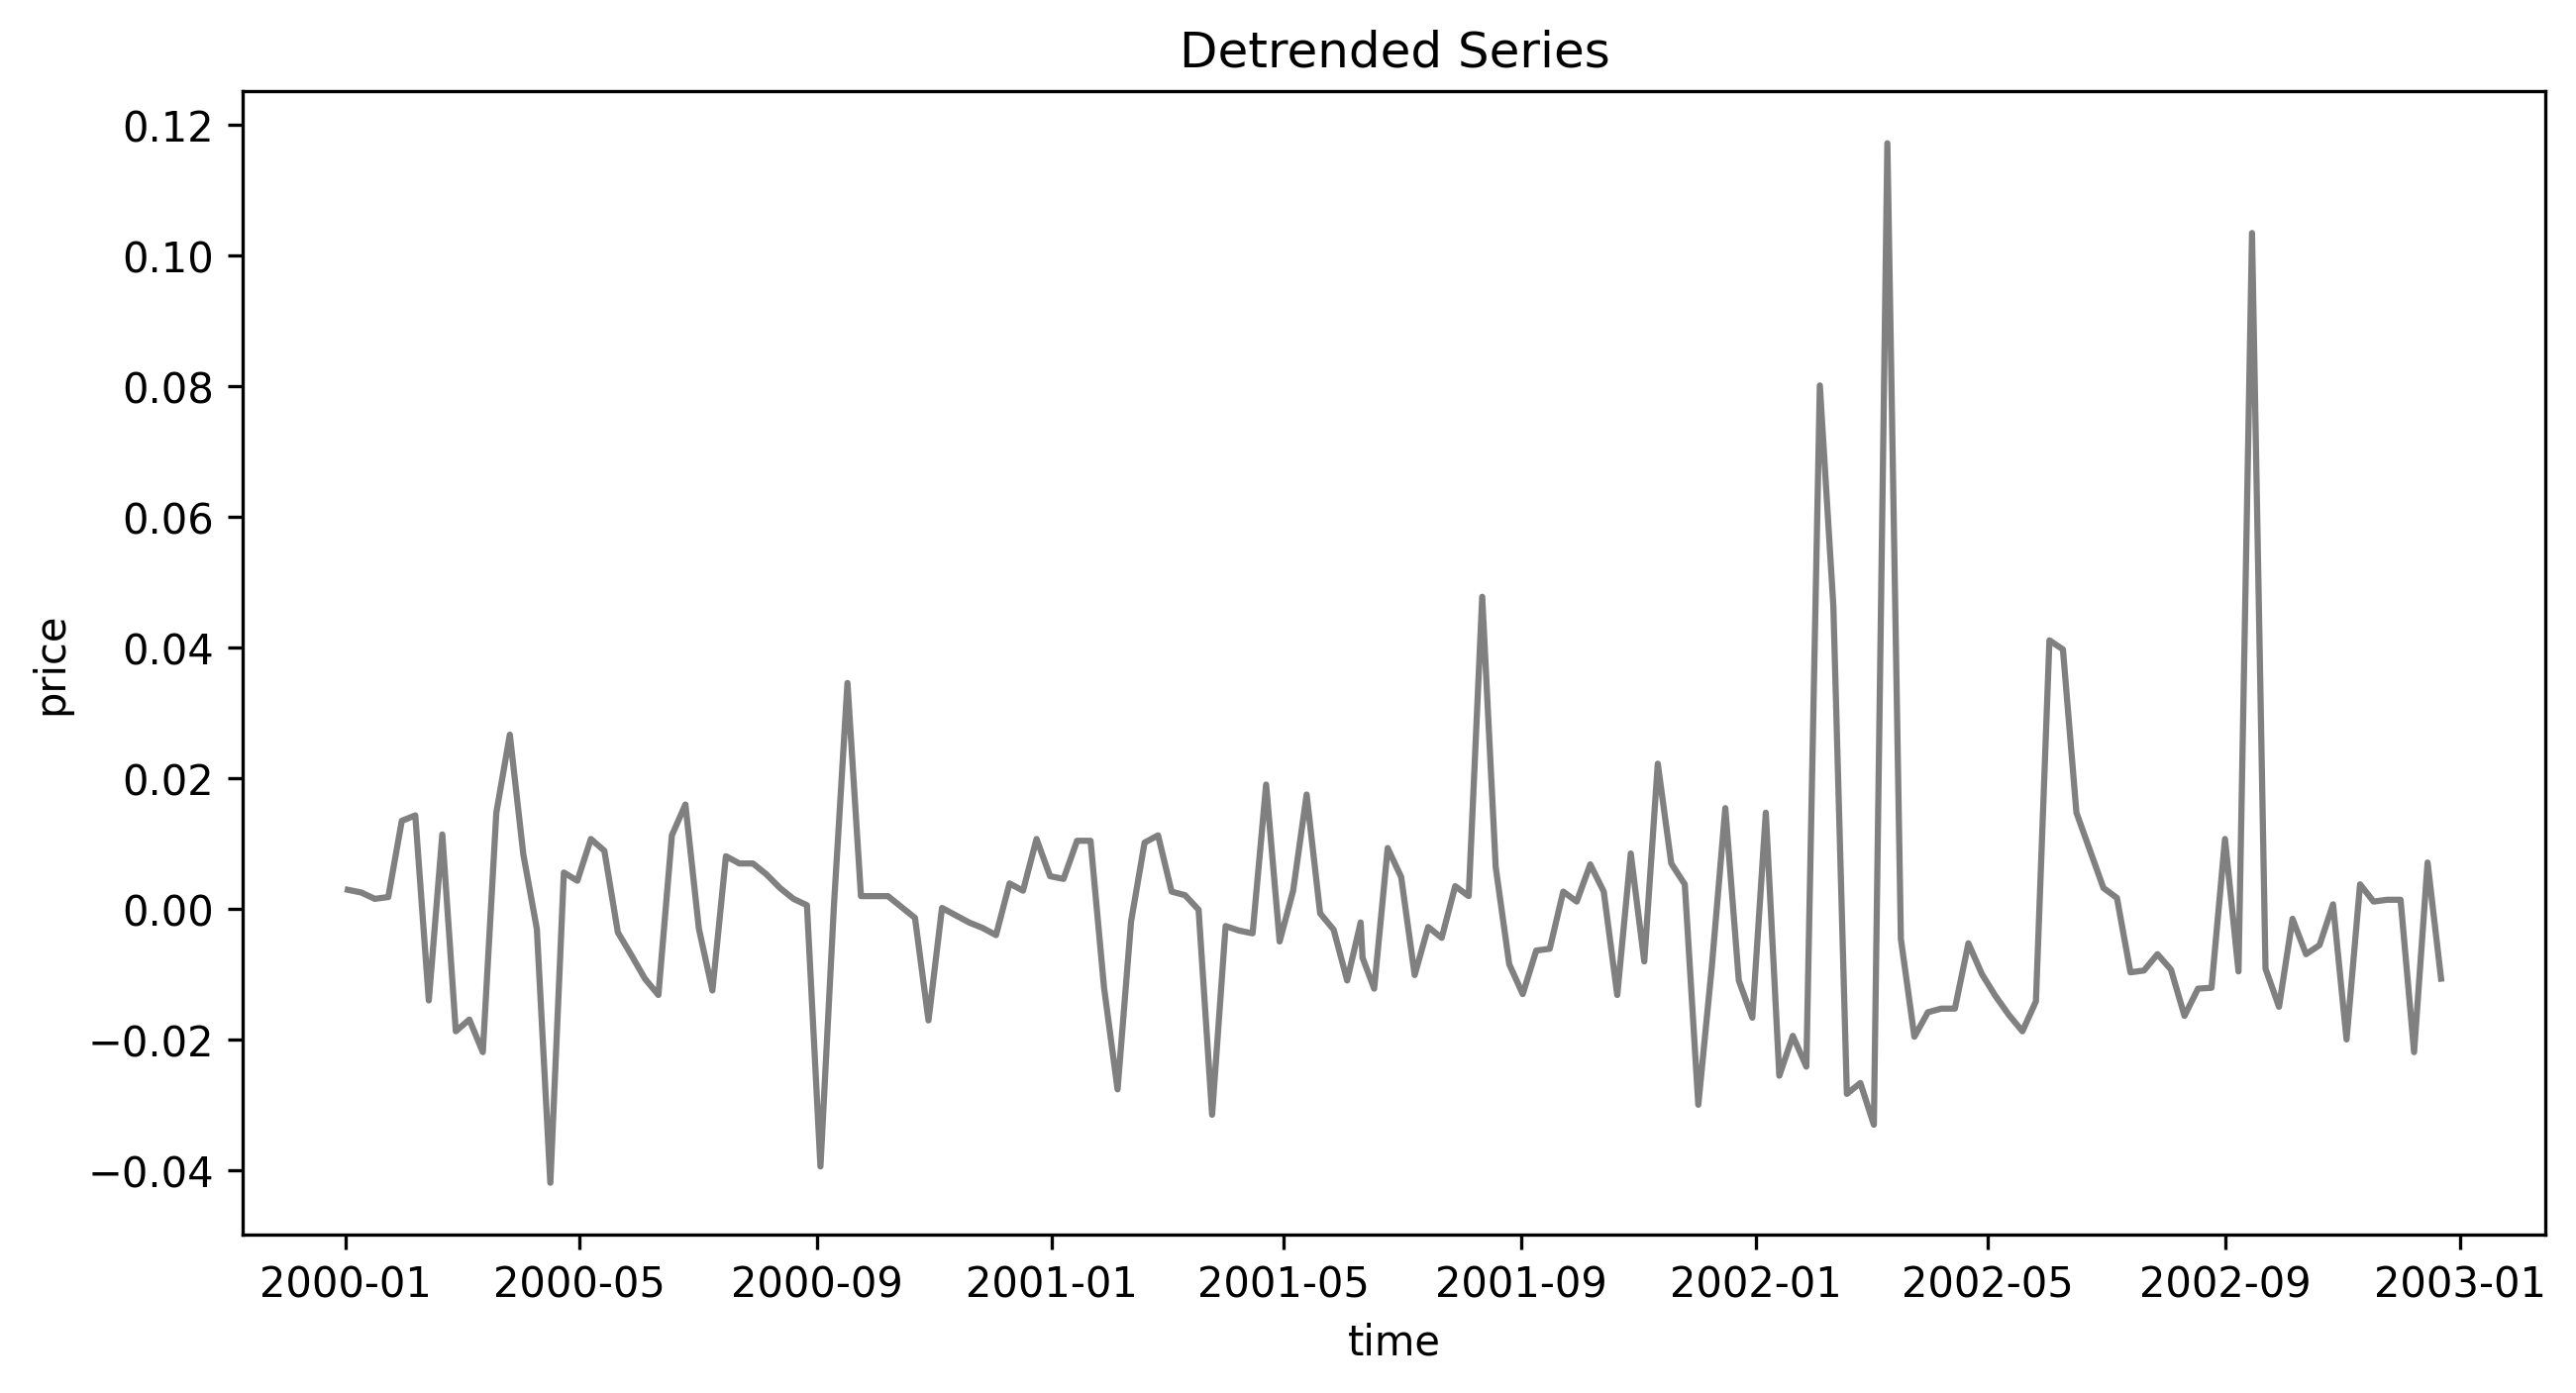

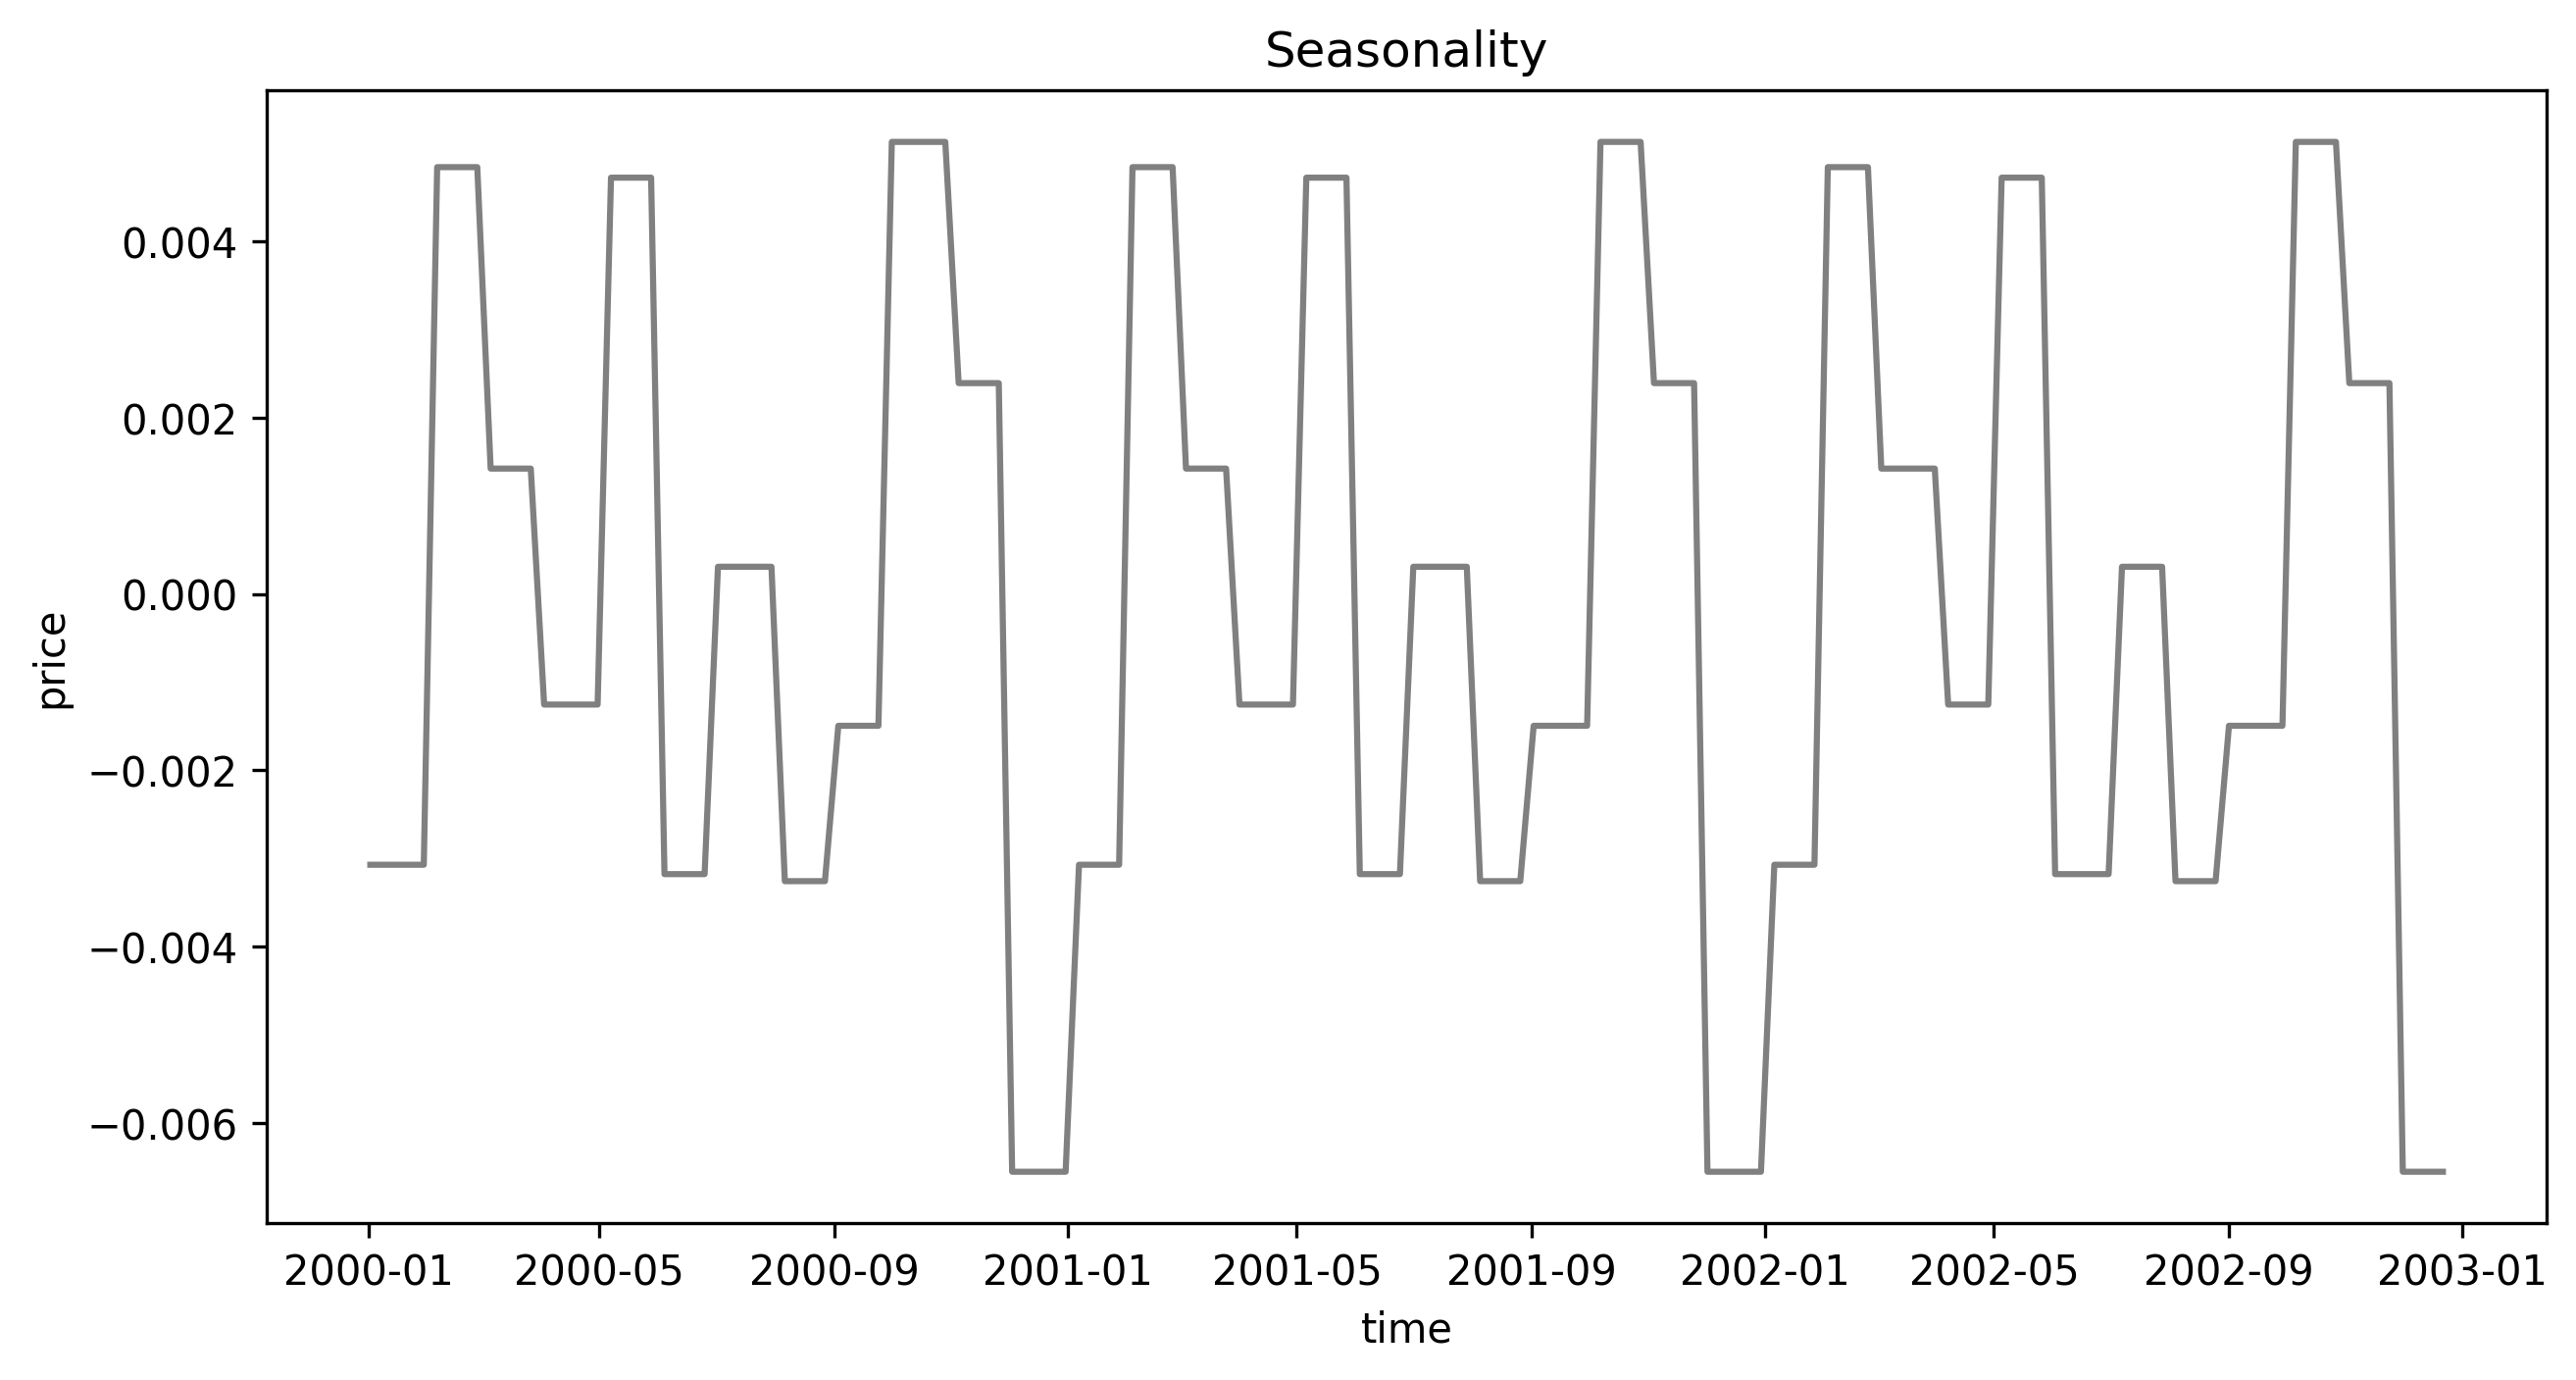

In [24]:
# plot original vs trend
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf['fruit'][10:166], marker='.', c='lightblue', label="Original Data")
plt.plot(ddf.index[10:166], ddf["trend_estimate"][10:166], color="gray", label="Estimated Trend")
plt.title("Trend Estimate Using Centered Moving Average (close-up on 2000-2002)")
plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()

# plot detrended
plt.figure(figsize=(10, 5), dpi=300)
# plt.plot(ddf.index[10:166], ddf['fruit'][10:166] - ddf['fruit'].mean(), marker='.', c='lightblue', label="Original Data")
plt.plot(ddf.index[10:166], ddf['detrended'][10:166], color='gray', label='detrended')
plt.title("Detrended Series")
# plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()

# plot seasonal component
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf['seasonal_estimate'][10:166], color='gray', label='seasonal estimate')
plt.title("Seasonality")
plt.xlabel("time")
plt.ylabel("price")
plt.show()

#### Similar process for s&p data

In [25]:
sp = pd.read_csv("cleaned_sp.csv", index_col='Date')
sp['Open']

Date
1999-10-25    1301.650024
1999-11-01    1362.930054
1999-11-08    1370.229980
1999-11-15    1396.060059
1999-11-22    1422.000000
                 ...     
2019-04-22    2898.780029
2019-04-29    2940.580078
2019-05-06    2908.889893
2019-05-13    2840.189941
2019-05-20    2841.939941
Name: Open, Length: 923, dtype: float64

In [26]:
sp.index = pd.to_datetime(sp.index)   # convert the index to datetime for convenience
sp = sp.sort_index()

# estimate trend using centered moving average (2x12)
sp["trend_estimate"] = sp["Open"].rolling(12).mean().rolling(2).mean().shift(-6)

# detrend and get seasonality
sp["detrended"] = sp["Open"] - sp["trend_estimate"]
seasonality = sp.groupby(sp.index.month)["detrended"].mean()
adjusted = seasonality - seasonality.mean()
sp["seasonal_estimate"] = sp.index.month.map(adjusted)

# get residuals
sp["residuals"] = sp["Open"] - sp["trend_estimate"]


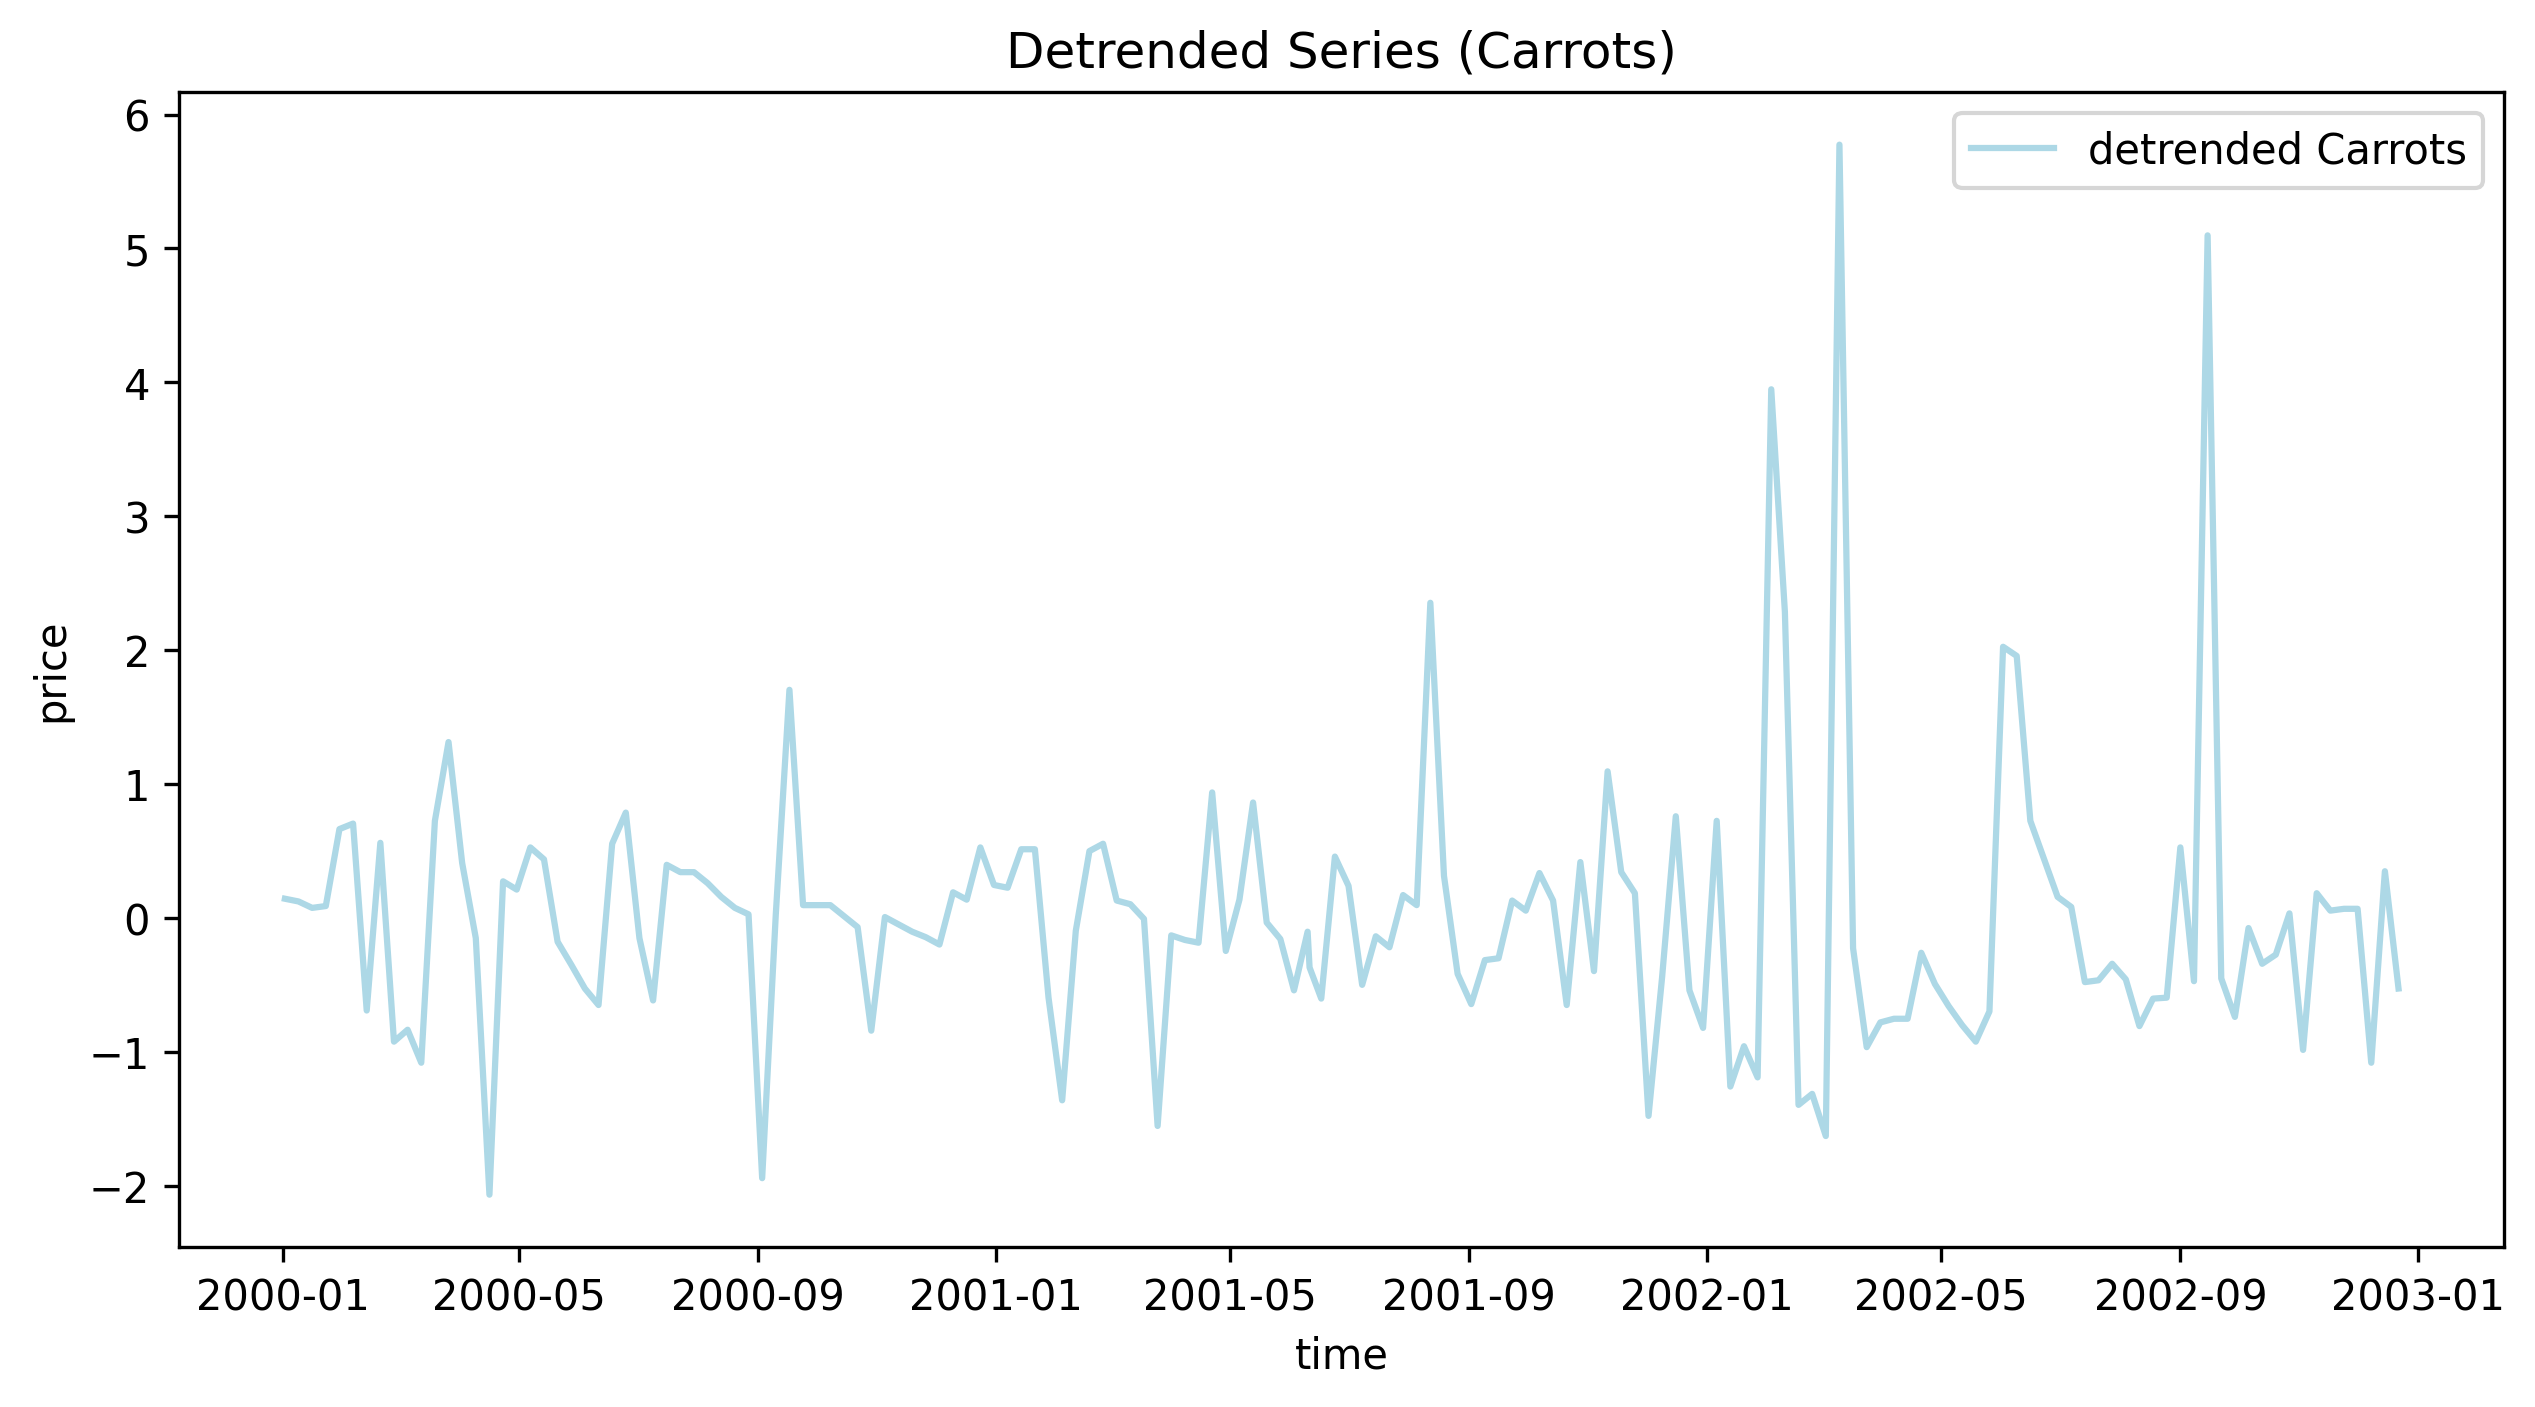

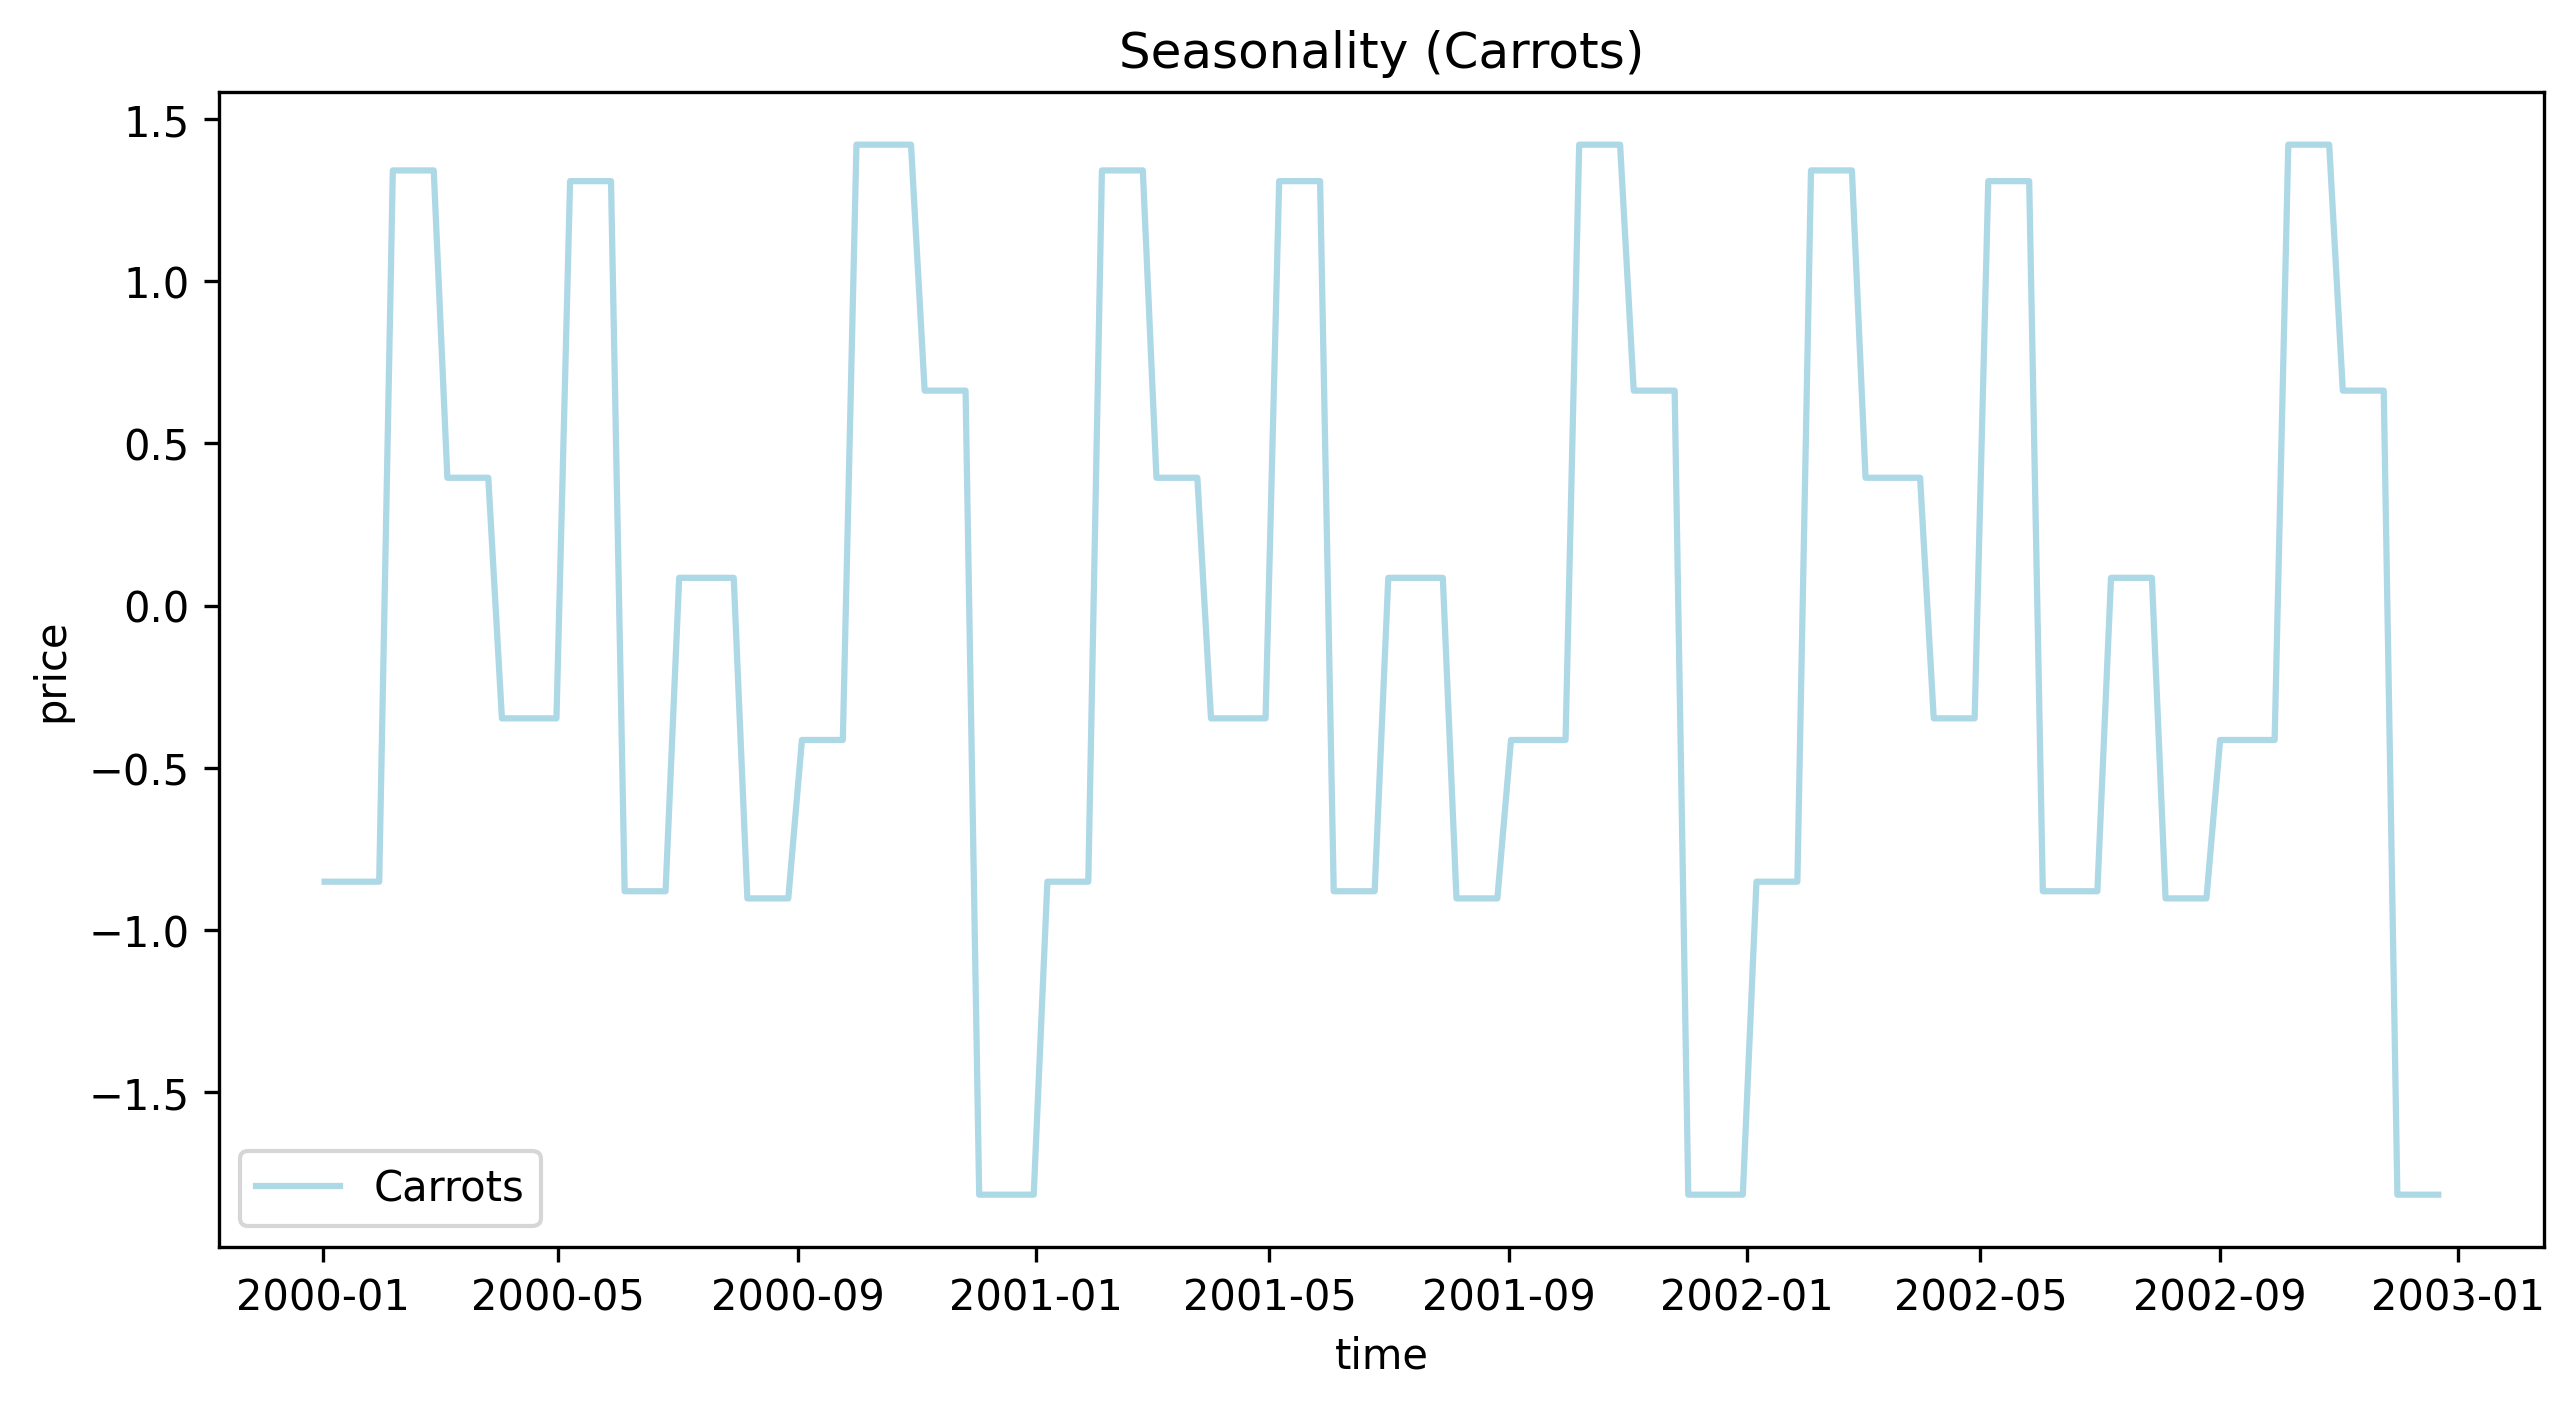

In [35]:
# plot original vs trend
# plt.figure(figsize=(10, 5), dpi=300)
# plt.plot(sp.index[10:166], sp['Open'][10:166], marker='.', c='lightblue', label="Original Data")
# # plt.plo t(sp.index[10:166], sp["trend_estimate"][10:166], color="gray", label="Estimated Trend")
# plt.title("Trend Estimate Using Centered Moving Average (close-up on 2000-2002)")
# plt.legend()
# plt.xlabel("time")
# plt.ylabel("price")
# plt.show()

# plot detrended
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf["detrended"][10:166] / ddf['detrended'][10:166].std(), color='lightblue', label=f'detrended {chosen_fruit.name}')
# plt.plot(sp.index[10:166], sp['detrended'][10:166] / sp['detrended'][10:166].std(), color='gray', label='detrended sp')
plt.title(f"Detrended Series ({chosen_fruit.name})")
plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()

# plot seasonal component
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf["seasonal_estimate"][10:166] / ddf['seasonal_estimate'][10:166].std(), color='lightblue', label=chosen_fruit.name)
# plt.plot(sp.index[10:166], sp['seasonal_estimate'][10:166] / sp['seasonal_estimate'][10:166].std(), color='gray', label='sp')
plt.title(f"Seasonality ({chosen_fruit.name})")
plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()